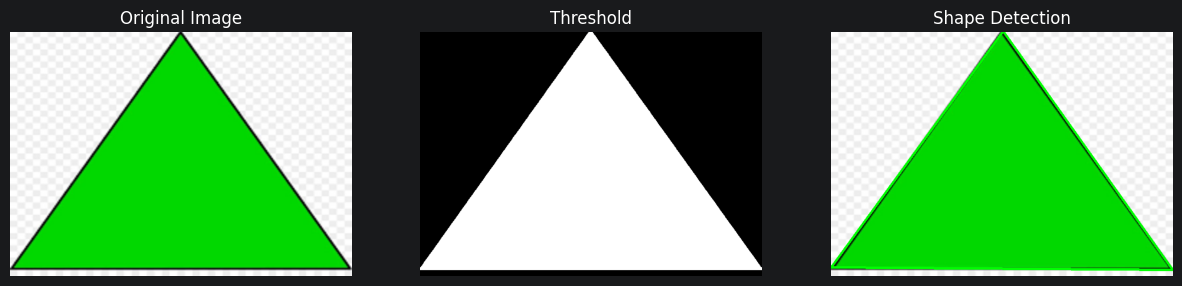

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# =========================
# ĐỌC ẢNH
# =========================
image = cv2.imread("img_data/tam_giac.jpg")

if image is None:
    print("Không đọc được ảnh")
    exit()

# Resize
image = cv2.resize(image, (700, 500))

# Copy ảnh gốc
output = image.copy()

# =========================
# TIỀN XỬ LÝ
# =========================

# Chuyển ảnh xám
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Làm mờ
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Threshold
_, thresh = cv2.threshold(
    blur,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# =========================
# KHỬ NHIỄU
# =========================
kernel = np.ones((3, 3), np.uint8)

thresh = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================
# TÌM CONTOUR
# =========================
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# =========================
# NHẬN DẠNG HÌNH
# =========================
for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 500:
        continue

    # Chu vi
    perimeter = cv2.arcLength(cnt, True)

    # Xấp xỉ đa giác
    approx = cv2.approxPolyDP(
        cnt,
        0.02 * perimeter,
        True
    )

    # Số đỉnh
    vertices = len(approx)

    # Bounding box
    x, y, w, h = cv2.boundingRect(approx)

    shape = "Unknown"

    # =========================
    # PHÂN LOẠI HÌNH
    # =========================

    if vertices == 3:
        shape = "Triangle"

    elif vertices == 4:

        ratio = w / float(h)

        if 0.95 <= ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"

    else:
        shape = "Circle"

    # =========================
    # VẼ KẾT QUẢ
    # =========================

    cv2.drawContours(
        output,
        [approx],
        -1,
        (0, 255, 0),
        3
    )

    cv2.putText(
        output,
        shape,
        (x, y - 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        3
    )

# =========================
# CHUYỂN BGR -> RGB
# =========================
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# =========================
# HIỂN THỊ
# =========================
plt.figure(figsize=(15, 5))

# Ảnh gốc
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# Threshold
plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")

# Kết quả
plt.subplot(1, 3, 3)
plt.imshow(output_rgb)
plt.title("Shape Detection")
plt.axis("off")

plt.show()